This one plots different files to visualize the salinity at high and low water slack across different distances with 3km increment from the mouth of the estuaries Dinh An and Tran De

In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parent

data_folder = (
    PROJECT_ROOT
    / "Data"
    / "Processed"
    / "Salinity measurements 2016"
)

# Find all cleaned CSV files
csv_files = list(data_folder.glob("*_cleaned.csv"))

print(f"Found {len(csv_files)} files")

Found 10 files


In [10]:
# This function plots a heatmap per one data file
def plot_salinity_heatmap(file_path, ax):

    # Read data
    df = pd.read_csv(file_path)

    # Reshape for heatmap
    salinity_matrix = df.pivot(
        index="depth_m",
        columns="distance_km",
        values="salinity_pss"
    )

    # Extract metadata from filename
    parts = file_path.stem.split("_")

    tidal = parts[1].upper()
    date_string = parts[3][:8]

    date = pd.to_datetime(
        date_string,
        format="%Y%m%d"
    )

    # Plot
    image = ax.imshow(
        salinity_matrix,
        aspect="auto",
        origin="upper",
        extent=[
            salinity_matrix.columns.min(),
            salinity_matrix.columns.max(),
            salinity_matrix.index.max(),
            salinity_matrix.index.min()
        ],
        vmin=0,
        vmax=30
    )

    ax.set_title(
        f"{date.strftime('%d %b %Y')} – {tidal}"
    )

    ax.set_xlabel("Distance upstream (km)")
    ax.set_ylabel("Depth (m)")

    return image

In [11]:
# Separate plots by measuring location Dinh An and Tran De
dinh_an_files = [file for file in csv_files if "_da_" in file.name]

tran_de_files = [file for file in csv_files if "_td_" in file.name]

In [12]:
# This function plots subplots for each location
def plot_location(files, location_name):

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(16, 9)
    )

    axes = axes.flatten()

    for ax, file_path in zip(axes, files):
        image = plot_salinity_heatmap(file_path, ax)

    # Hide unused subplot
    for ax in axes[len(files):]:
        ax.set_visible(False)

    fig.suptitle(
        f"Salinity Profiles – {location_name}",
        fontsize=16
    )

    # One colorbar shared by all heatmaps
    fig.colorbar(
        image,
        ax=axes.tolist(),
        label="Salinity (PSS)",
        shrink=0.8
    )

    plt.show()

Subplots for Dinh An's salinity

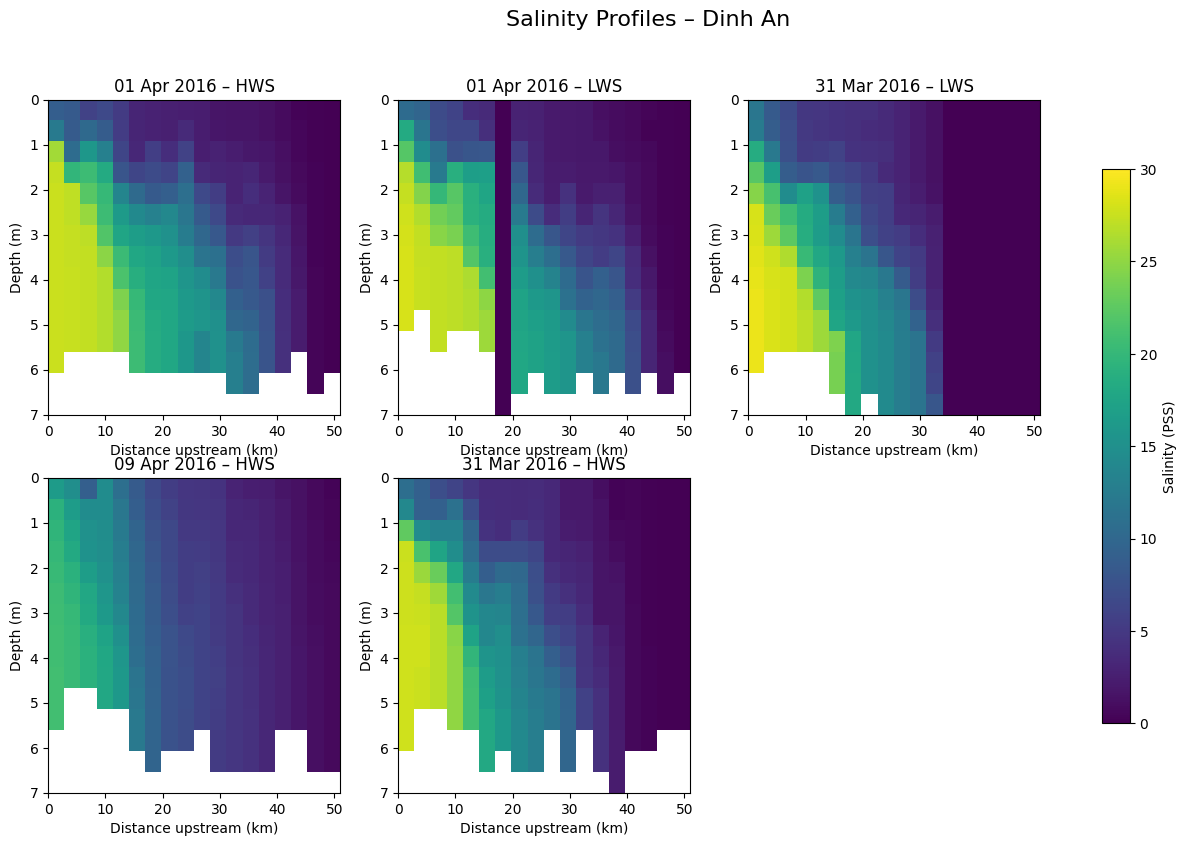

In [13]:
plot_location(dinh_an_files, "Dinh An")

Subplots for Tran De

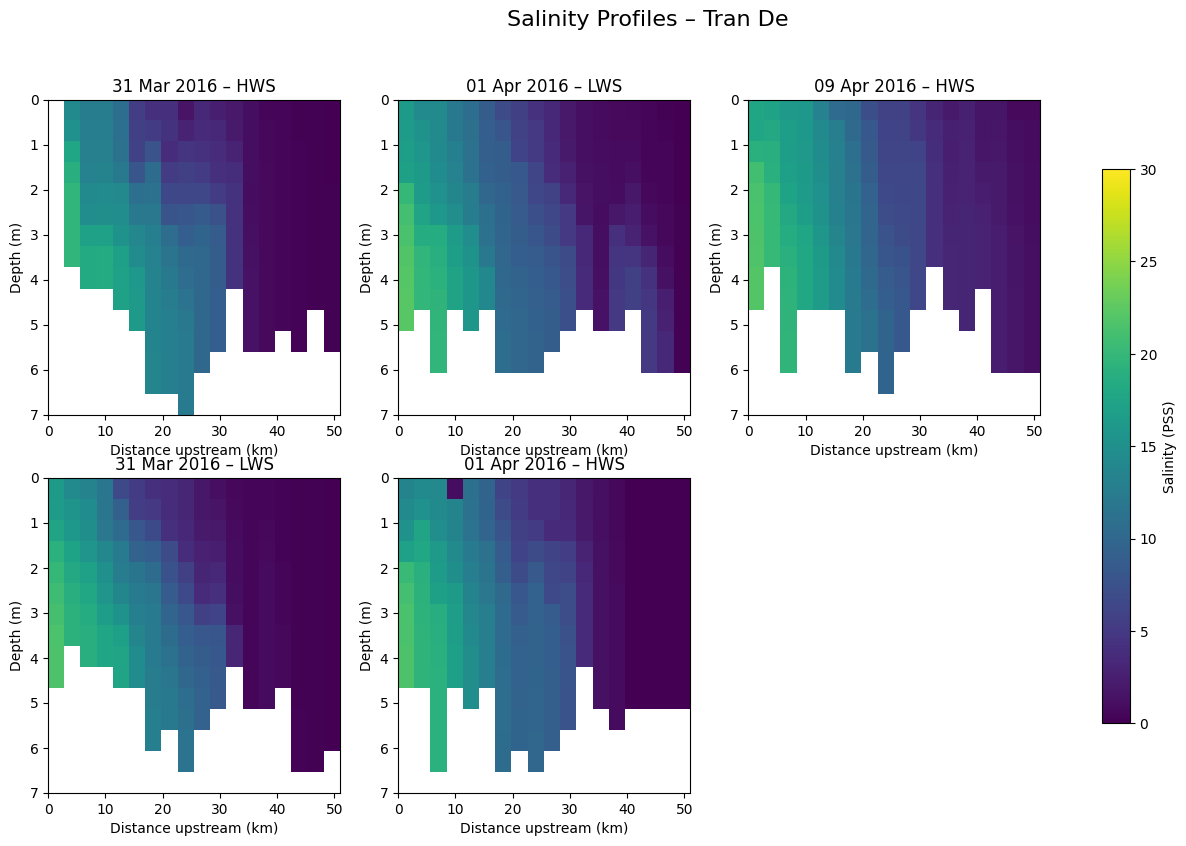

In [14]:
plot_location(tran_de_files, "Tran De")